# TNG300-1: descendants at $z=0$ of $M_{200c}\simeq10^{11}\,M_\odot$ halos at $z\simeq8$

This notebook constructs

$$p\!\left(M_{200c,z=0}\mid 10^{10.8}<M_{200c,z\simeq8}/M_\odot<10^{11.2}\right)$$

using TNG300-1 FoF group catalogs and SubLink. The selected object at $z\simeq8$ is each FoF halo's central subhalo (`GroupFirstSub`). It is followed along its unique `DescendantID` chain. At $z=0$, the mass assigned to it is **not** `SubhaloMass`; it is the `Group_M_Crit200` of the FoF host containing the descendant subhalo. Thus, descendants that have become satellites are assigned their final host-halo mass.

## Cell 1: imports and plotting defaults

In [1]:
from pathlib import Path
from collections import Counter
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from tqdm.auto import tqdm
import illustris_python as il

plt.rcParams.update({
    "figure.figsize": (7.0, 4.8),
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})

## Cell 2: simulation path and parameters

The existing notebooks in `~/tng-work/` use the sibling-directory layout `../sims.TNG/<simulation>/output/`; the TNG300-1 path below follows that layout. The group-catalog header is used to verify both the redshift and cosmological $h$, rather than silently relying on hard-coded conversion factors.

In [2]:
basePath = Path("../sims.TNG/TNG300-1/output/").expanduser().resolve()
if not basePath.is_dir():
    raise FileNotFoundError(
        f"TNG300-1 output directory was not found at {basePath}. "
        "If this JupyterLab uses a different mount point, edit basePath only."
    )

snap_z8 = 8
snap_z0 = 99
logM_min = 10.8
logM_max = 11.2

header_z8 = il.groupcat.loadHeader(str(basePath), snap_z8)
header_z0 = il.groupcat.loadHeader(str(basePath), snap_z0)
z_z8 = float(header_z8["Redshift"])
h = float(header_z8["HubbleParam"])

# Check locally that snapshot 8 is closer to z=8 than its immediate neighbors.
neighbor_redshifts = {
    s: float(il.groupcat.loadHeader(str(basePath), s)["Redshift"])
    for s in (snap_z8 - 1, snap_z8 + 1)
}
assert abs(z_z8 - 8.0) <= min(abs(z - 8.0) for z in neighbor_redshifts.values())
assert np.isclose(h, 0.6774, rtol=0, atol=1e-4), f"Unexpected TNG300 h={h}"

print(f"basePath              : {basePath}")
print(f"z≈8 snapshot          : {snap_z8}")
print(f"snapshot {snap_z8} redshift : {z_z8:.6f}")
print(f"z=0 snapshot          : {snap_z0} (z={float(header_z0['Redshift']):.6f})")
print(f"Hubble parameter h    : {h:.4f}")

basePath              : /home/tnguser/sims.TNG/L205n2500TNG/output
z≈8 snapshot          : 8
snapshot 8 redshift : 8.012173
z=0 snapshot          : 99 (z=0.000000)
Hubble parameter h    : 0.6774


## Cell 3: load the $z\simeq8$ FoF catalog

TNG catalog masses are stored in units of $10^{10}\,M_\odot/h$. Therefore

$$M[M_\odot] = M[10^{10}M_\odot/h]\,10^{10}/h.$$

In [3]:
halo_fields_z8 = ["Group_M_Crit200", "GroupFirstSub"]
halos_z8 = il.groupcat.loadHalos(str(basePath), snap_z8, fields=halo_fields_z8)

group_m200c_z8_code = np.asarray(halos_z8["Group_M_Crit200"])
group_first_sub_z8 = np.asarray(halos_z8["GroupFirstSub"], dtype=np.int64)
M200c_z8_Msun = group_m200c_z8_code * 1.0e10 / h

logM200c_z8 = np.full(M200c_z8_Msun.shape, np.nan, dtype=float)
positive_mass_z8 = M200c_z8_Msun > 0
logM200c_z8[positive_mass_z8] = np.log10(M200c_z8_Msun[positive_mass_z8])

print(f"Loaded {len(M200c_z8_Msun):,} FoF halos at snapshot {snap_z8}.")
print("Mass conversion: Group_M_Crit200 × 1e10 / h -> physical Msun")

Loaded 4,706,171 FoF halos at snapshot 8.
Mass conversion: Group_M_Crit200 × 1e10 / h -> physical Msun


## Cell 4: select the $z\simeq8$ halo sample

In [4]:
mass_mask = (
    positive_mass_z8
    & (logM200c_z8 > logM_min)
    & (logM200c_z8 < logM_max)
)
sample_mask = mass_mask & (group_first_sub_z8 >= 0)
group_ids_z8 = np.flatnonzero(sample_mask).astype(np.int64)

sample = pd.DataFrame({
    "GroupID_z8": group_ids_z8,
    "SubhaloID_z8": group_first_sub_z8[sample_mask],
    "M200c_z8": M200c_z8_Msun[sample_mask],
    "logM200c_z8": logM200c_z8[sample_mask],
})

print(f"All z≈8 FoF halos          : {len(M200c_z8_Msun):,}")
print(f"Halos passing mass cut     : {mass_mask.sum():,}")
print(f"Final sample (has central) : {len(sample):,}")
if len(sample):
    print(
        "M200c(z≈8) [Msun], min / median / max: "
        f"{sample.M200c_z8.min():.4e} / "
        f"{sample.M200c_z8.median():.4e} / "
        f"{sample.M200c_z8.max():.4e}"
    )
else:
    raise RuntimeError("The z≈8 selection is empty; verify basePath, snapshot, and mass units.")

display(sample.head())

All z≈8 FoF halos          : 4,706,171
Halos passing mass cut     : 3,099
Final sample (has central) : 3,099
M200c(z≈8) [Msun], min / median / max: 6.3098e+10 / 8.2144e+10 / 1.5846e+11


,GroupID_z8,SubhaloID_z8,M200c_z8,logM200c_z8
0,36,494,1.419282e+11,11.152069
1,40,537,1.576432e+11,11.197676
2,65,747,1.261118e+11,11.100756
3,77,846,1.427720e+11,11.154643
4,80,867,1.465733e+11,11.166055


## Cell 5: $z\simeq8$ mass distribution

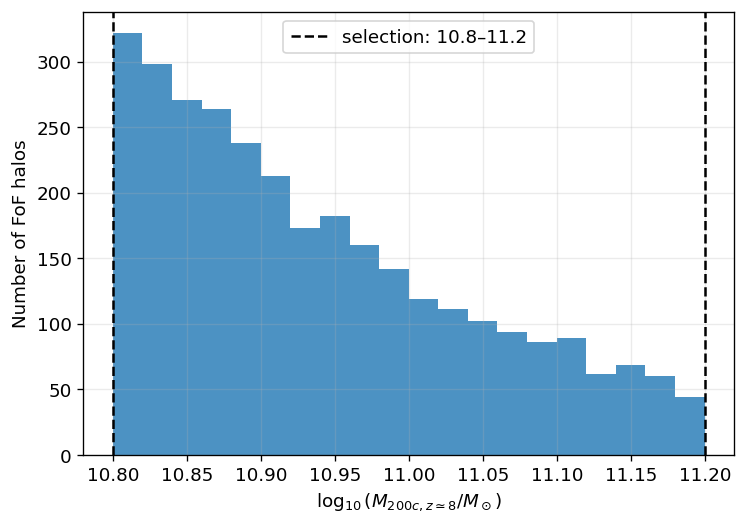

In [5]:
fig, ax = plt.subplots()
ax.hist(sample["logM200c_z8"], bins=20, color="tab:blue", alpha=0.8)
ax.axvline(logM_min, color="k", ls="--", label=f"selection: {logM_min:.1f}–{logM_max:.1f}")
ax.axvline(logM_max, color="k", ls="--")
ax.set(xlabel=r"$\log_{10}(M_{200c,z\simeq8}/M_\odot)$", ylabel="Number of FoF halos")
ax.legend()
plt.show()

## Cell 6: test SubLink on one halo

`onlyMDB=True` restricts the read to the main-descendant-side tree cutout. A cutout can nevertheless contain more than one row at a snapshot when the starting object is not on the final object's main progenitor branch. Consequently, later cells explicitly walk `SubhaloID -> DescendantID`; they do not assume that an arbitrary `SnapNum == 99` row is the correct descendant.

`SubhaloGrNr` is attempted here because some tree products include it. If absent, the notebook deliberately obtains it from the snapshot-99 subhalo catalog in Cell 7, which is the authoritative mapping needed for the final FoF host.

In [6]:
test_row = sample.iloc[0]
test_group_z8 = int(test_row["GroupID_z8"])
test_sub_z8 = int(test_row["SubhaloID_z8"])

tree_fields = ["SnapNum", "SubfindID", "SubhaloID", "DescendantID", "SubhaloMass"]
try:
    tree_test = il.sublink.loadTree(
        str(basePath), snap_z8, test_sub_z8,
        fields=tree_fields + ["SubhaloGrNr"], onlyMDB=True
    )
    tree_has_group_number = True
except Exception as exc:
    if "SubhaloGrNr" not in str(exc):
        raise
    tree_test = il.sublink.loadTree(
        str(basePath), snap_z8, test_sub_z8,
        fields=tree_fields, onlyMDB=True
    )
    tree_has_group_number = False

if tree_test is None:
    raise RuntimeError(f"Test subhalo {test_sub_z8} is absent from SubLink.")

print(f"Test z≈8 Group ID     : {test_group_z8}")
print(f"Test z≈8 Subfind ID   : {test_sub_z8}")
print(f"Tree has SubhaloGrNr  : {tree_has_group_number}")
print("Tree snapshots        :", np.asarray(tree_test["SnapNum"]))
print("Tree Subfind IDs      :", np.asarray(tree_test["SubfindID"]))
print(f"Cutout contains z=0   : {np.any(np.asarray(tree_test['SnapNum']) == snap_z0)}")

Test z≈8 Group ID     : 36
Test z≈8 Subfind ID   : 494
Tree has SubhaloGrNr  : True
Tree snapshots        : [99 98 97 96 95 94 93 92 91 90 89 88 87 86 85 84 83 82 81 80 79 78 77 76
 75 74 73 72 71 70 69 68 67 66 65 64 63 62 61 60 59 58 57 56 55 54 53 52
 51 50 49 48 47 46 45 44 43 42 41 40 39 38 37 36 35 34 33 32 31 30 29 28
 27 26 25 24 23 22 21 20 19 18 17 16 15 14 13 12 11 10  9]
Tree Subfind IDs      : [ 11750  11665  11635  11670  11782  11651  11738  14472  11817  11874
  12034  11998  12085  12138  12054  12009   6882   6534 212657 210055
 208781 204066 206203 201915 197195 194377 192331 187934 179086 197556
 192286 191038 160890 157162 153900 147183 167277 218235 422920 249915
 410941 401342 389716 381651 369019 356404 346701 335303 323361 304624
 291777 273117 274545 228005 226452 208099 188142 169616 150655 130125
 120689 109220  99614  91143  81933  73682  69162  72435  62575  53855
  43302  33376  49741  41292  34951  38005  35249  29074  26501  24093
  17662   6076   8108 

## Cell 7: load the $z=0$ subhalo-to-host mapping and FoF masses once

These arrays are loaded once and reused for every tree. `SubhaloGrNr[subfind_id]` gives the FoF host at snapshot 99, including when the tracked descendant is a satellite.

In [7]:
subhalo_grnr_z0 = np.asarray(
    il.groupcat.loadSubhalos(str(basePath), snap_z0, fields=["SubhaloGrNr"]),
    dtype=np.int64,
)
group_m200c_z0_code = np.asarray(
    il.groupcat.loadHalos(str(basePath), snap_z0, fields=["Group_M_Crit200"])
)
M200c_z0_Msun = group_m200c_z0_code * 1.0e10 / h

print(f"z=0 subhalos loaded : {len(subhalo_grnr_z0):,}")
print(f"z=0 FoF halos loaded: {len(M200c_z0_Msun):,}")

z=0 subhalos loaded : 14,485,709
z=0 FoF halos loaded: 17,625,892


## Cell 8: obtain the test halo's $z=0$ descendant host mass

In [9]:
def z0_descendant_row(tree, end_snap):
    """Return the unique snapshot-end row in an onlyMDB SubLink cutout.

    The input subhalo itself need not be present when it is not on the main
    progenitor branch of its root descendant. The z=0 root descendant is,
    however, included in the onlyMDB result.
    """
    snap = np.asarray(tree["SnapNum"])
    rows = np.flatnonzero(snap == end_snap)

    if rows.size != 1:
        raise ValueError(
            f"Expected one descendant at snapshot {end_snap}, found {rows.size}"
        )

    return int(rows[0])


test_z0_row = z0_descendant_row(tree_test, snap_z0)
test_sub_z0 = int(np.asarray(tree_test["SubfindID"])[test_z0_row])

if not (0 <= test_sub_z0 < len(subhalo_grnr_z0)):
    raise IndexError(f"Invalid z=0 SubfindID: {test_sub_z0}")

test_group_z0 = int(subhalo_grnr_z0[test_sub_z0])

if not (0 <= test_group_z0 < len(M200c_z0_Msun)):
    raise IndexError(f"Invalid z=0 FoF Group ID: {test_group_z0}")

test_m200c_z0 = float(M200c_z0_Msun[test_group_z0])

print(f"z=8 Group ID                : {test_group_z8}")
print(f"z=8 central Subhalo ID      : {test_sub_z8}")
print(f"M200c(z=8) [Msun]           : {test_row['M200c_z8']:.6e}")
print()
print(f"z=0 descendant Subhalo ID   : {test_sub_z0}")
print(f"z=0 host Group ID           : {test_group_z0}")
print(f"z=0 host M200c [Msun]       : {test_m200c_z0:.6e}")

z=8 Group ID                : 36
z=8 central Subhalo ID      : 494
M200c(z=8) [Msun]           : 1.419282e+11

z=0 descendant Subhalo ID   : 11750
z=0 host Group ID           : 1
z=0 host M200c [Msun]       : 1.307340e+15


## Cell 9: descendant-host lookup function

In [10]:
def get_z0_descendant_host_mass(
    subhalo_id_z8,
    base_path=basePath,
    start_snap=snap_z8,
    end_snap=snap_z0,
    subhalo_host_z0=subhalo_grnr_z0,
    host_m200c_z0=M200c_z0_Msun,
    return_reason=False,
):
    """Return z=0 Subfind ID, FoF ID, and host M200c for one z≈8 subhalo."""

    failure = (np.nan, np.nan, np.nan)

    try:
        sid8 = int(subhalo_id_z8)

        tree = il.sublink.loadTree(
            str(base_path),
            start_snap,
            sid8,
            fields=[
                "SnapNum",
                "SubfindID",
                "SubhaloID",
                "DescendantID",
            ],
            onlyMDB=True,
        )

        if tree is None:
            result, reason = failure, "not_in_tree"

        else:
            try:
                row0 = z0_descendant_row(tree, end_snap)
            except ValueError:
                result, reason = failure, "no_unique_z0_descendant"
            else:
                sub0 = int(np.asarray(tree["SubfindID"])[row0])

                if not (0 <= sub0 < len(subhalo_host_z0)):
                    result, reason = failure, "invalid_z0_subfind_id"

                else:
                    group0 = int(subhalo_host_z0[sub0])

                    if not (0 <= group0 < len(host_m200c_z0)):
                        result, reason = failure, "invalid_z0_group_id"

                    else:
                        mass0 = float(host_m200c_z0[group0])

                        if not np.isfinite(mass0) or mass0 <= 0:
                            result, reason = failure, "nonpositive_z0_m200c"
                        else:
                            result = (sub0, group0, mass0)
                            reason = "success"

    except Exception as exc:
        result = failure
        reason = f"exception:{type(exc).__name__}"

    return (*result, reason) if return_reason else result


print(
    "Test function output:",
    get_z0_descendant_host_mass(test_sub_z8),
)

Test function output: (11750, 1, 1307340129173504.0)


## Cell 10: track the full sample and save the baseline table

In [11]:
tracked = [
    get_z0_descendant_host_mass(sid, return_reason=True)
    for sid in tqdm(sample["SubhaloID_z8"].to_numpy(), desc="Forward tracking")
]

sample[["SubhaloID_z0", "GroupID_z0", "M200c_z0", "TrackingStatus"]] = pd.DataFrame(
    tracked, index=sample.index
)
sample["logM200c_z0"] = np.where(
    sample["M200c_z0"].to_numpy() > 0,
    np.log10(sample["M200c_z0"].to_numpy()),
    np.nan,
)

column_order = [
    "GroupID_z8", "SubhaloID_z8", "M200c_z8", "logM200c_z8",
    "SubhaloID_z0", "GroupID_z0", "M200c_z0", "logM200c_z0",
    "TrackingStatus",
]
sample = sample[column_order]

output_csv = Path.cwd() / "tng300_z8_M11_descendants.csv"
sample.to_csv(output_csv, index=False)
print(f"Saved: {output_csv}")
display(sample.head())

Forward tracking:   0%|          | 0/3099 [00:00<?, ?it/s]

Saved: /home/tnguser/tng-work/tng300_z8_M11_descendants.csv


,GroupID_z8,SubhaloID_z8,M200c_z8,logM200c_z8,SubhaloID_z0,GroupID_z0,M200c_z0,logM200c_z0,TrackingStatus
0,36,494,1.419282e+11,11.152069,11750,1,1.307340e+15,15.116389,success
1,40,537,1.576432e+11,11.197676,260599,128,1.676412e+14,14.224381,success
2,65,747,1.261118e+11,11.100756,47315,8,3.982516e+14,14.600158,success
3,77,846,1.427720e+11,11.154643,427248,332,9.975454e+13,13.998933,success
4,80,867,1.465733e+11,11.166055,503347,473,8.107555e+13,13.908890,success


## Cell 11: tracking completeness

Failures are retained as `NaN`. Typical physical/technical causes are: the selected subhalo is absent from the tree offsets, its descendant chain terminates before snapshot 99 (e.g. disruption), or an ID/catalog consistency check fails. The diagnostic counts below distinguish these cases.

In [12]:
success = sample["M200c_z0"].notna()
n_total = len(sample)
n_success = int(success.sum())
n_failed = n_total - n_success
success_fraction = n_success / n_total if n_total else np.nan

print(f"Total selected halos       : {n_total:,}")
print(f"z=0 descendants recovered : {n_success:,}")
print(f"Tracking success fraction : {success_fraction:.3%}")
print(f"Failed halos              : {n_failed:,}")
print("\nStatus counts:")
display(sample["TrackingStatus"].value_counts(dropna=False).rename("count").to_frame())

if n_success == 0:
    raise RuntimeError("No z=0 descendants were recovered; inspect the status counts above.")
valid = sample.loc[success].copy()

Total selected halos       : 3,099
z=0 descendants recovered : 3,099
Tracking success fraction : 100.000%
Failed halos              : 0

Status counts:


,count
TrackingStatus,
success,3099


## Cell 12: $z=0$ descendant host-mass distribution

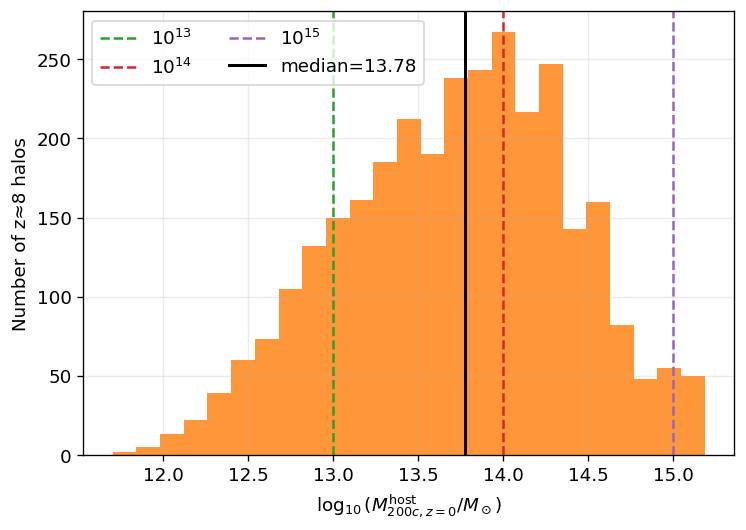

log10 M200c(z=0) median       : 13.779
log10 M200c(z=0) 16–84 pct.   : [13.012, 14.386]
M200c(z=0) median [Msun]      : 6.0129e+13
M200c(z=0) 16–84 pct. [Msun]  : [1.0288e+13, 2.4311e+14]


In [13]:
q16, median_logM0, q84 = np.percentile(valid["logM200c_z0"], [16, 50, 84])

fig, ax = plt.subplots()
ax.hist(valid["logM200c_z0"], bins=25, color="tab:orange", alpha=0.82)
for x, label, color in [
    (13, r"$10^{13}$", "tab:green"),
    (14, r"$10^{14}$", "tab:red"),
    (15, r"$10^{15}$", "tab:purple"),
]:
    ax.axvline(x, ls="--", color=color, label=label)
ax.axvline(median_logM0, color="k", lw=1.8, label=f"median={median_logM0:.2f}")
ax.set(xlabel=r"$\log_{10}(M_{200c,z=0}^{\rm host}/M_\odot)$", ylabel="Number of z≈8 halos")
ax.legend(ncol=2)
plt.show()

print(f"log10 M200c(z=0) median       : {median_logM0:.3f}")
print(f"log10 M200c(z=0) 16–84 pct.   : [{q16:.3f}, {q84:.3f}]")
print(f"M200c(z=0) median [Msun]      : {10**median_logM0:.4e}")
print(f"M200c(z=0) 16–84 pct. [Msun]  : [{10**q16:.4e}, {10**q84:.4e}]")

## Cell 13: initial mass versus descendant host mass

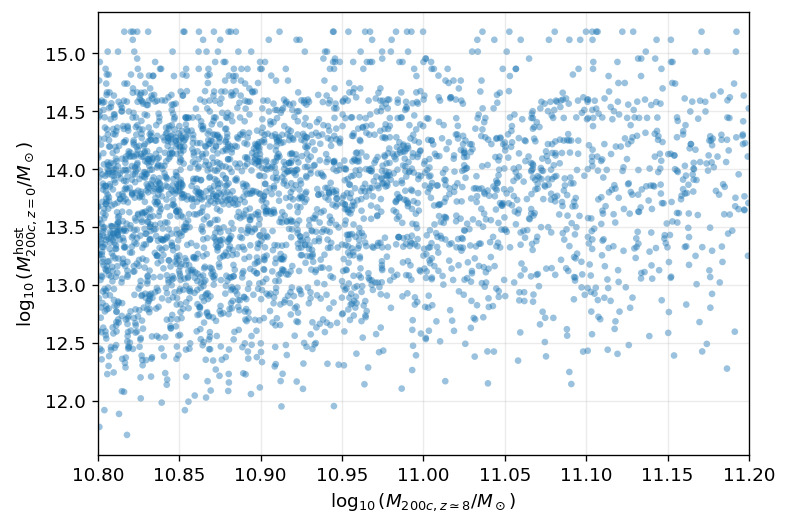

In [14]:
fig, ax = plt.subplots()
ax.scatter(
    valid["logM200c_z8"], valid["logM200c_z0"],
    s=16, alpha=0.45, edgecolors="none",
)
ax.set(
    xlabel=r"$\log_{10}(M_{200c,z\simeq8}/M_\odot)$",
    ylabel=r"$\log_{10}(M_{200c,z=0}^{\rm host}/M_\odot)$",
    xlim=(logM_min, logM_max),
)
plt.show()

## Cell 14: survival function of descendant host mass

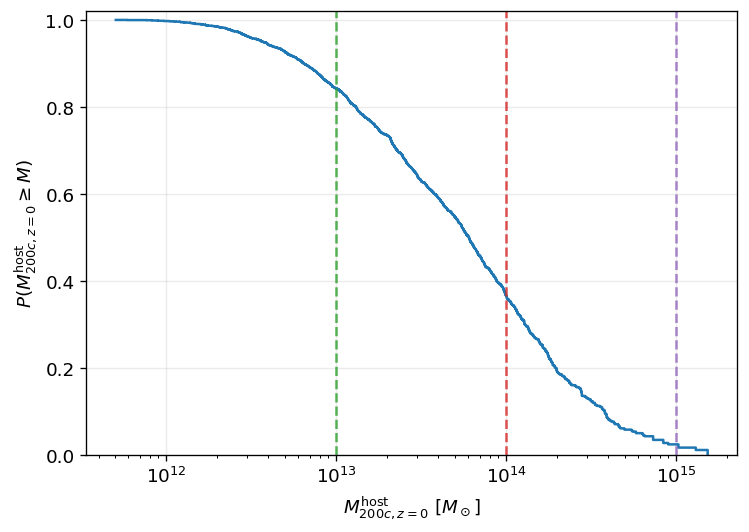

In [15]:
mass_sorted = np.sort(valid["M200c_z0"].to_numpy())
survival = (len(mass_sorted) - np.arange(len(mass_sorted))) / len(mass_sorted)

fig, ax = plt.subplots()
ax.step(mass_sorted, survival, where="post", color="tab:blue")
for threshold, color in [(1e13, "tab:green"), (1e14, "tab:red"), (1e15, "tab:purple")]:
    ax.axvline(threshold, ls="--", color=color, alpha=0.8)
ax.set_xscale("log")
ax.set(
    xlabel=r"$M_{200c,z=0}^{\rm host}\ [M_\odot]$",
    ylabel=r"$P(M_{200c,z=0}^{\rm host}\geq M)$",
    ylim=(0, 1.02),
)
plt.show()

## Cell 15: group, cluster, and Coma-like fractions

Fractions below are conditional on successful tracking. Quoted uncertainties are approximate 68% Wilson binomial intervals; this remains informative when a measured fraction is zero or one.

In [16]:
def wilson_interval(k, n, z=1.0):
    if n == 0:
        return np.nan, np.nan
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2*n)) / denom
    half = z * np.sqrt(p*(1-p)/n + z**2/(4*n**2)) / denom
    return center - half, center + half


m0 = valid["M200c_z0"].to_numpy()
categories = {
    "low-mass / galaxy halo (<1e13)": m0 < 1e13,
    "group (1e13–1e14)": (m0 >= 1e13) & (m0 < 1e14),
    "cluster (1e14–1e15)": (m0 >= 1e14) & (m0 < 1e15),
    "Coma-like (>=1e15)": m0 >= 1e15,
}

category_rows = []
for label, mask in categories.items():
    k = int(mask.sum())
    lo, hi = wilson_interval(k, n_success)
    category_rows.append((label, k, k/n_success, lo, hi))
fractions = pd.DataFrame(
    category_rows, columns=["Class", "N", "Fraction", "Wilson68_lo", "Wilson68_hi"]
)
display(fractions.style.format({"Fraction": "{:.3%}", "Wilson68_lo": "{:.3%}", "Wilson68_hi": "{:.3%}"}))

tail_probabilities = {}
for threshold in (1e13, 1e14, 1e15):
    k = int((m0 > threshold).sum())
    p = k / n_success
    lo, hi = wilson_interval(k, n_success)
    tail_probabilities[threshold] = p
    print(f"P(M0 > {threshold:.0e} Msun) = {p:.3%}  (N={k}/{n_success}; Wilson 68%: {lo:.3%}–{hi:.3%})")

,Class,N,Fraction,Wilson68_lo,Wilson68_hi
0,low-mass / galaxy halo (<1e13),488,15.747%,15.104%,16.412%
1,group (1e13–1e14),1479,47.725%,46.829%,48.623%
2,cluster (1e14–1e15),1059,34.172%,33.326%,35.029%
3,Coma-like (>=1e15),73,2.356%,2.098%,2.644%


P(M0 > 1e+13 Msun) = 84.253%  (N=2611/3099; Wilson 68%: 83.588%–84.896%)
P(M0 > 1e+14 Msun) = 36.528%  (N=1132/3099; Wilson 68%: 35.667%–37.397%)
P(M0 > 1e+15 Msun) = 2.356%  (N=73/3099; Wilson 68%: 2.098%–2.644%)


## Cell 16: duplicate-descendant analysis

Different selected $z\simeq8$ halos may merge into the same snapshot-99 FoF halo. For comparisons between JWST protocluster abundance and $z=0$ cluster abundance, treating all such $z\simeq8$ halos as independent protoclusters can therefore double count a common descendant.

Unique z=0 descendant FoF halos       : 1,761
z=0 halos with >1 z≈8 sample halo    : 533
Maximum progenitor multiplicity      : 33


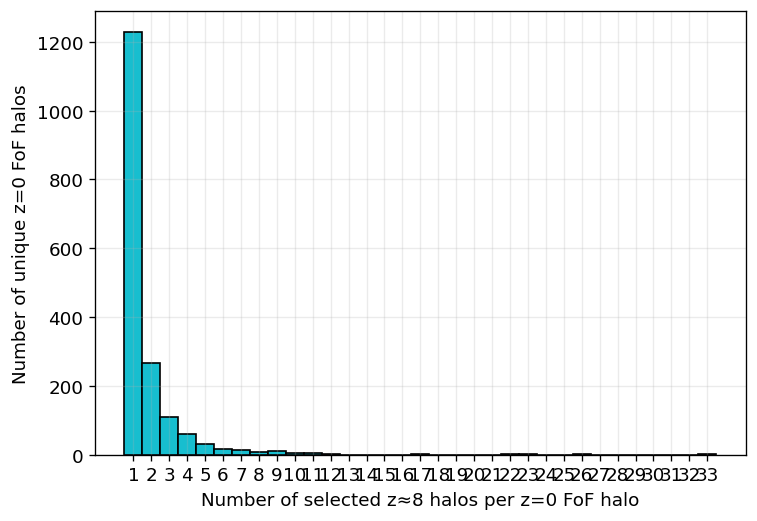

In [17]:
multiplicity = (
    valid.assign(GroupID_z0=valid["GroupID_z0"].astype(np.int64))
    .groupby("GroupID_z0")
    .size()
    .sort_values(ascending=False)
)
n_unique_descendants = len(multiplicity)
n_multi_descendants = int((multiplicity > 1).sum())
max_multiplicity = int(multiplicity.max())

print(f"Unique z=0 descendant FoF halos       : {n_unique_descendants:,}")
print(f"z=0 halos with >1 z≈8 sample halo    : {n_multi_descendants:,}")
print(f"Maximum progenitor multiplicity      : {max_multiplicity:,}")

fig, ax = plt.subplots()
bins = np.arange(0.5, max_multiplicity + 1.5, 1)
ax.hist(multiplicity.to_numpy(), bins=bins, color="tab:cyan", edgecolor="k")
ax.set(
    xlabel="Number of selected z≈8 halos per z=0 FoF halo",
    ylabel="Number of unique z=0 FoF halos",
    xticks=np.arange(1, max_multiplicity + 1),
)
plt.show()

## Cell 17: one representative progenitor per unique descendant

For each snapshot-99 FoF halo, retain the selected $z\simeq8$ progenitor with the largest $M_{200c}$ and compare its descendant-mass distribution with the halo-level distribution.

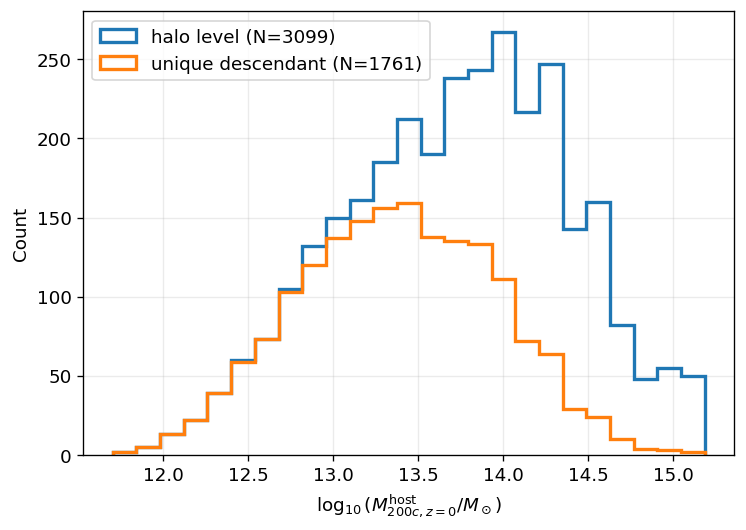

In [18]:
unique_descendant_sample = (
    valid.assign(GroupID_z0=valid["GroupID_z0"].astype(np.int64))
    .sort_values("M200c_z8", ascending=False)
    .drop_duplicates("GroupID_z0", keep="first")
    .sort_index()
)

common_bins = np.linspace(
    valid["logM200c_z0"].min(), valid["logM200c_z0"].max(), 26
)
fig, ax = plt.subplots()
ax.hist(
    valid["logM200c_z0"], bins=common_bins, histtype="step", lw=2,
    label=f"halo level (N={len(valid)})",
)
ax.hist(
    unique_descendant_sample["logM200c_z0"], bins=common_bins,
    histtype="step", lw=2, label=f"unique descendant (N={len(unique_descendant_sample)})",
)
ax.set(xlabel=r"$\log_{10}(M_{200c,z=0}^{\rm host}/M_\odot)$", ylabel="Count")
ax.legend()
plt.show()

## Automatically generated summary

In [19]:
scatter_68_dex = q84 - q16
multi_object_fraction = n_multi_descendants / n_unique_descendants if n_unique_descendants else np.nan

display(Markdown(f'''
### Summary

1. At $z={z_z8:.3f}$ (snapshot {snap_z8}), **{n_total:,}** FoF halos satisfy
   $10^{{{logM_min:.1f}}}<M_{{200c}}/M_\odot<10^{{{logM_max:.1f}}}$ and have a central subhalo.
2. A $z=0$ descendant host was recovered for **{n_success:,}/{n_total:,} ({success_fraction:.2%})** objects. Its mass has median
   $\log_{{10}}(M_{{200c}}/M_\odot)={median_logM0:.3f}$ and 16–84 percentile range **[{q16:.3f}, {q84:.3f}]**.
3. The conditional tail fractions are **{tail_probabilities[1e13]:.2%}** above $10^{{13}}M_\odot$,
   **{tail_probabilities[1e14]:.2%}** above $10^{{14}}M_\odot$, and
   **{tail_probabilities[1e15]:.2%}** above $10^{{15}}M_\odot$ (Coma-like).
4. Despite the narrow initial mass interval, the central 68% descendant-host range spans **{scatter_68_dex:.3f} dex**.
5. The sample maps to **{n_unique_descendants:,}** unique $z=0$ FoF halos. **{n_multi_descendants:,} ({multi_object_fraction:.2%})**
   have more than one selected $z\simeq8$ progenitor, with maximum multiplicity **{max_multiplicity}**.

All descendant masses above are snapshot-99 **FoF host** `Group_M_Crit200`, not descendant `SubhaloMass`.
'''))


### Summary

1. At $z=8.012$ (snapshot 8), **3,099** FoF halos satisfy
   $10^{10.8}<M_{200c}/M_\odot<10^{11.2}$ and have a central subhalo.
2. A $z=0$ descendant host was recovered for **3,099/3,099 (100.00%)** objects. Its mass has median
   $\log_{10}(M_{200c}/M_\odot)=13.779$ and 16–84 percentile range **[13.012, 14.386]**.
3. The conditional tail fractions are **84.25%** above $10^{13}M_\odot$,
   **36.53%** above $10^{14}M_\odot$, and
   **2.36%** above $10^{15}M_\odot$ (Coma-like).
4. Despite the narrow initial mass interval, the central 68% descendant-host range spans **1.373 dex**.
5. The sample maps to **1,761** unique $z=0$ FoF halos. **533 (30.27%)**
   have more than one selected $z\simeq8$ progenitor, with maximum multiplicity **33**.

All descendant masses above are snapshot-99 **FoF host** `Group_M_Crit200`, not descendant `SubhaloMass`.
